[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JMasr/audio-ml-tutorials/blob/main/es/whisper-peft-lora.ipynb)

Autor: José Manuel Ramírez Sánchez · https://jmramirez.engineer

# PEFT + LoRA sobre Whisper: clasificador *downstream* vs. extractor de embeddings

Este notebook es un tutorial directo -- pensado para quien ya trabaja con
embeddings de modelos SSL de voz -- sobre cómo aplicar **PEFT (Parameter-Efficient
Fine-Tuning)** con adaptadores **LoRA** a un modelo **Whisper**, en dos
modalidades de uso:

1. **Clasificador vía *downstream task***: Whisper + una cabeza de clasificación
   entrenada de extremo a extremo, con el backbone congelado y LoRA inyectado en
   la atención del encoder.
2. **Extractor de características (embeddings)**: el backbone de Whisper se
   mantiene congelado (sin cabeza de tarea permanente) y se le añaden adaptadores
   LoRA para que los *embeddings* que produce se puedan consumir con un
   clasificador externo -- el mismo patrón que un pipeline de embeddings SSL
   (HuBERT/WavLM/XLSR/AST) con mean-pooling + un clasificador `scikit-learn`
   dentro de tu validación cruzada.

En ambos casos:
- El backbone preentrenado se **congela** (`requires_grad = False`).
- Se insertan adaptadores LoRA solo en **puntos estratégicos** de las capas del
  encoder -- y esos puntos son *distintos* según la modalidad (se explica en
  cada sección por qué).
- Solo se entrena una fracción muy pequeña de los parámetros totales.

**Diseño de este notebook:**
- Corre enteramente en **CPU** (no requiere CUDA ni GPU) -- evita cualquier
  problema de compatibilidad entre `torch` y los drivers de CUDA de tu máquina.
- Usa **datos sintéticos** (tonos senoidales generados con `numpy`) en vez de
  audio real, para que todo el notebook corra en pocos minutos y no dependa de
  ningún dataset externo.
- Usa `openai/whisper-tiny` (~39M parámetros), el checkpoint más pequeño de la
  familia Whisper, para que el entrenamiento sea rápido en CPU.

> Tiempo estimado total: **~4 minutos** en una CPU de 8 núcleos sin GPU (incluida la descarga del modelo).

**Requisitos:** instala las dependencias antes de empezar (en Colab, en una
celda con `%pip install ...`):

```bash
pip install torch transformers==4.57.6 peft==0.20.0 scikit-learn matplotlib
```

## 0. ¿Qué es LoRA, en una página?

LoRA (*Low-Rank Adaptation*) congela una matriz de pesos preentrenada
$W_0 \in \mathbb{R}^{d\times k}$ y aprende, en paralelo, una actualización de
**bajo rango**:

$$ W = W_0 + \Delta W = W_0 + B A, \qquad B \in \mathbb{R}^{d\times r},\ A \in \mathbb{R}^{r\times k},\ r \ll \min(d,k) $$

Solo $A$ y $B$ se entrenan; $W_0$ nunca cambia. Como $r$ es pequeño (típicamente
4-32), el número de parámetros entrenables es una fracción mínima del modelo
completo. Los hiperparámetros clave (los volveremos a ver en el código):

| Hiperparámetro | Qué controla |
|---|---|
| `r` | rango de la actualización -- más alto = más capacidad, más parámetros |
| `lora_alpha` | factor de escala de $\Delta W$ (el escalado real es `alpha / r`) |
| `lora_dropout` | dropout aplicado a la rama LoRA durante el entrenamiento |
| `target_modules` | **qué capas** reciben el adaptador -- esto es lo que cambia entre las dos modalidades de este notebook |
| `modules_to_save` | capas que se entrenan **por completo** (sin LoRA), típicamente cabezas nuevas sin preentrenar |

¿Por qué congelar y adaptar en vez de *fine-tunear* todo? Con un backbone
congelado: (a) el coste de memoria/cómputo del entrenamiento cae drásticamente
(clave para poder iterar en CPU, como aquí), (b) el checkpoint resultante es un
adaptador de unos pocos MB en vez de duplicar el modelo base, y (c) se reduce el
riesgo de *catastrophic forgetting* del conocimiento preentrenado.

In [1]:
import os

# Fuerza CPU de forma explícita e independiente de la máquina donde corra esto
# -- evita cualquier intento de inicializar CUDA (y posibles conflictos con el
# driver de la GPU: aquí ni siquiera la necesitamos).
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import torch

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device("cpu")

import peft
import transformers

print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("peft        :", peft.__version__)
print("device      :", DEVICE, "| cuda disponible:", torch.cuda.is_available())

torch       : 2.13.0+cpu
transformers: 4.57.6
peft        : 0.20.0
device      : cpu | cuda disponible: False


## 1. Datos sintéticos

En vez de audio real, generamos "utterances" sintéticas: tonos senoidales de
1 segundo a 16 kHz (la tasa de muestreo que espera Whisper) con dos clases
definidas por su frecuencia base, más ruido gaussiano. No hay ninguna pretensión
de realismo acústico -- el objetivo es tener una señal barata de generar y
*aprendible*, para poder verificar que el flujo LoRA realmente entrena algo.

Con datos reales, esta celda se reemplazaría por tu cargador de datos (y las
etiquetas 0/1 serían, por ejemplo, sano / patológico).

In [2]:
SAMPLE_RATE = 16_000  # requerido por WhisperFeatureExtractor
DURATION_S = 1.0
CLASS_FREQS = (220.0, 660.0)  # Hz -- una clase por frecuencia base
NOISE_STD = 0.05


def make_example(label: int, rng: np.random.Generator) -> np.ndarray:
    # Un tono senoidal de 1s con jitter de frecuencia + ruido gaussiano.
    t = np.linspace(0, DURATION_S, int(SAMPLE_RATE * DURATION_S), endpoint=False)
    base_freq = CLASS_FREQS[label]
    freq = base_freq * (1 + 0.05 * rng.standard_normal())  # +/-5% de jitter
    wave = 0.3 * np.sin(2 * np.pi * freq * t)
    wave += NOISE_STD * rng.standard_normal(t.shape)
    return wave.astype(np.float32)


def make_dataset(n_per_class: int, seed: int) -> tuple[list[np.ndarray], list[int]]:
    rng = np.random.default_rng(seed)
    waves, labels = [], []
    for label in (0, 1):
        for _ in range(n_per_class):
            waves.append(make_example(label, rng))
            labels.append(label)
    return waves, labels


train_waves, train_labels = make_dataset(n_per_class=10, seed=2)
val_waves, val_labels = make_dataset(n_per_class=4, seed=3)
print(f"train: {len(train_waves)} ejemplos | val: {len(val_waves)} ejemplos")

train: 20 ejemplos | val: 8 ejemplos


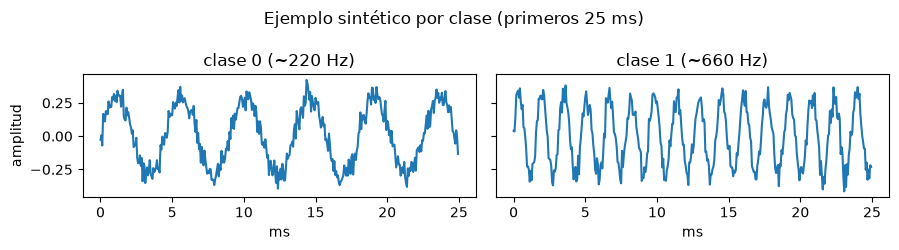

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 2.5), sharey=True)
for ax, label in zip(axes, (0, 1)):
    idx = train_labels.index(label)
    axes_t = np.arange(400) / SAMPLE_RATE * 1000
    ax.plot(axes_t, train_waves[idx][:400])
    ax.set_title(f"clase {label} (~{CLASS_FREQS[label]:.0f} Hz)")
    ax.set_xlabel("ms")
axes[0].set_ylabel("amplitud")
fig.suptitle("Ejemplo sintético por clase (primeros 25 ms)")
fig.tight_layout()
plt.show()

## 2. Feature extractor de Whisper

`WhisperFeatureExtractor` convierte la forma de onda cruda en un espectrograma
log-mel (80 bandas). Un detalle importante para lo que sigue: **Whisper siempre
opera sobre una ventana fija de 30 segundos** -- el feature extractor rellena
(pad) cualquier clip más corto hasta 3000 frames mel, y el encoder los reduce a
1500 posiciones tras la convolución con stride 2. Esto significa que el coste de
cómputo por clip es constante, independientemente de que nuestro audio sintético
dure solo 1 segundo.

In [4]:
from transformers import WhisperFeatureExtractor

CHECKPOINT = "openai/whisper-tiny"
feature_extractor = WhisperFeatureExtractor.from_pretrained(CHECKPOINT)

sample_features = feature_extractor(train_waves[:2], sampling_rate=SAMPLE_RATE, return_tensors="pt")
print("input_features shape:", sample_features["input_features"].shape)  # (batch, 80 mel bins, 3000 frames)


def to_batch(waves: list[np.ndarray], labels: list[int]) -> tuple[torch.Tensor, torch.Tensor]:
    feats = feature_extractor(waves, sampling_rate=SAMPLE_RATE, return_tensors="pt")
    return feats["input_features"], torch.tensor(labels)


X_train, y_train = to_batch(train_waves, train_labels)
X_val, y_val = to_batch(val_waves, val_labels)

input_features shape: torch.Size([2, 80, 3000])


## 3. Parte A -- Whisper como clasificador vía *downstream task*

Usamos `WhisperForAudioClassification`: el encoder de Whisper + una capa
`projector` + *pooling* + una cabeza `classifier` lineal. `projector` y
`classifier` se inicializan aleatoriamente (no vienen del checkpoint
preentrenado), así que **tienen que entrenarse por completo**; el resto del
encoder puede quedarse congelado salvo por los adaptadores LoRA.

**Puntos estratégicos para esta modalidad:** solo `q_proj` y `v_proj` de la
autoatención de cada capa del encoder. Para una *decisión* de clasificación
basta con dejar que el adaptador reajuste ligeramente **a qué presta atención**
el encoder; no hace falta tocar las proyecciones feed-forward (`fc1`/`fc2`) que
sí adaptaremos en la Parte B.

In [5]:
from transformers import WhisperForAudioClassification

classifier_model = WhisperForAudioClassification.from_pretrained(CHECKPOINT, num_labels=2)

n_frozen = sum(p.numel() for p in classifier_model.parameters())
print(f"Parámetros totales (antes de PEFT): {n_frozen:,}")

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-tiny and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parámetros totales (antes de PEFT): 8,307,458


In [6]:
from peft import LoraConfig, get_peft_model

classifier_lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],       # solo atención del encoder
    modules_to_save=["projector", "classifier"],  # cabeza nueva -> se entrena entera
)

peft_classifier = get_peft_model(classifier_model, classifier_lora_config)
peft_classifier.print_trainable_parameters()

trainable params: 148,226 || all params: 8,455,684 || trainable%: 1.7530


In [7]:
import time

optimizer = torch.optim.AdamW(
    [p for p in peft_classifier.parameters() if p.requires_grad], lr=1e-3
)


def accuracy(model, X, y) -> float:
    model.eval()
    with torch.no_grad():
        logits = model(input_features=X).logits
    return (logits.argmax(dim=-1) == y).float().mean().item()


print(f"val accuracy antes de entrenar (backbone congelado, LoRA sin entrenar): {accuracy(peft_classifier, X_val, y_val):.3f}")

BATCH_SIZE = 4
N_EPOCHS = 3
n_train = X_train.shape[0]

t0 = time.time()
peft_classifier.train()
for epoch in range(N_EPOCHS):
    perm = torch.randperm(n_train)
    for i in range(0, n_train, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        optimizer.zero_grad()
        out = peft_classifier(input_features=X_train[idx], labels=y_train[idx])
        out.loss.backward()
        optimizer.step()
    peft_classifier.eval()
    print(
        f"época {epoch} | loss {out.loss.item():.4f} "
        f"| train acc {accuracy(peft_classifier, X_train, y_train):.3f} "
        f"| val acc {accuracy(peft_classifier, X_val, y_val):.3f} "
        f"| {time.time() - t0:.1f}s"
    )
    peft_classifier.train()

print(f"\nEntrenamiento completo en {time.time() - t0:.1f}s (CPU)")

val accuracy antes de entrenar (backbone congelado, LoRA sin entrenar): 0.500


época 0 | loss 0.6387 | train acc 0.500 | val acc 0.500 | 9.5s


época 1 | loss 0.2567 | train acc 1.000 | val acc 1.000 | 21.0s


época 2 | loss 0.0042 | train acc 1.000 | val acc 1.000 | 50.6s

Entrenamiento completo en 50.6s (CPU)


### 3.1 Guardar y recargar solo el adaptador

Uno de los mayores beneficios prácticos de PEFT: el checkpoint que hay que
guardar son solo las matrices LoRA (+ las capas en `modules_to_save`), no el
modelo completo. Lo comprobamos guardando y comparando tamaños en disco.

In [8]:
import tempfile
from pathlib import Path

from peft import PeftModel


def dir_size_mb(path: Path) -> float:
    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e6


with tempfile.TemporaryDirectory() as tmp_dir:
    adapter_dir = Path(tmp_dir) / "whisper_tiny_classifier_lora"
    peft_classifier.save_pretrained(adapter_dir)
    adapter_mb = dir_size_mb(adapter_dir)
    print(f"Tamaño del adaptador guardado: {adapter_mb:.2f} MB")
    print(f"Parámetros totales del modelo base: {n_frozen:,} (~{n_frozen * 4 / 1e6:.1f} MB en fp32)")

    # Recarga: backbone base "limpio" + adaptador guardado
    base_for_reload = WhisperForAudioClassification.from_pretrained(CHECKPOINT, num_labels=2)
    reloaded = PeftModel.from_pretrained(base_for_reload, adapter_dir)
    print(f"val accuracy tras recargar el adaptador: {accuracy(reloaded, X_val, y_val):.3f}")

Tamaño del adaptador guardado: 0.60 MB
Parámetros totales del modelo base: 8,307,458 (~33.2 MB en fp32)


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-tiny and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


val accuracy tras recargar el adaptador: 1.000


## 4. Parte B -- Whisper como extractor de embeddings congelado + LoRA

Aquí no hay cabeza de clasificación permanente: el objetivo es producir un
**vector de embedding** por clip (igual que tu pipeline de embeddings SSL hace
con HuBERT/WavLM/XLSR/AST) que luego se pueda consumir con **cualquier**
clasificador externo -- típicamente un clasificador `scikit-learn` dentro de tu
validación cruzada.

**Puntos estratégicos para esta modalidad:** además de `q_proj`/`v_proj`,
añadimos LoRA en `fc1`/`fc2` (las proyecciones feed-forward de cada capa del
encoder). La diferencia con la Parte A es intencional: allí solo hacía falta
mover una *frontera de decisión* aguas abajo de una cabeza entrenable; aquí no
hay cabeza que absorba el ajuste -- es el **embedding mismo** el que tiene que
desplazarse, y las capas feed-forward son las que más remodelan la
representación en cada bloque transformer.

Truco de entrenamiento: como no queremos "hornear" una tarea concreta dentro del
extractor, le acoplamos temporalmente una cabeza lineal (*probe*) de usar y
tirar, solo para poder retropropagar una señal supervisada hacia los adaptadores
LoRA. Al terminar, descartamos el *probe* y nos quedamos únicamente con el
encoder + LoRA como extractor de embeddings.

In [9]:
from transformers import WhisperModel

whisper_full = WhisperModel.from_pretrained(CHECKPOINT)
encoder = whisper_full.get_encoder()

embedding_lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "fc1", "fc2"],  # atención + feed-forward
)

peft_encoder = get_peft_model(encoder, embedding_lora_config)
peft_encoder.print_trainable_parameters()

trainable params: 86,016 || all params: 8,294,400 || trainable%: 1.0370


In [10]:
def embed(model, X: torch.Tensor) -> torch.Tensor:
    # Mean-pooling sobre el eje temporal del último hidden state -- la misma
    # estrategia de pooling habitual con HuBERT/WavLM/XLSR en pipelines SSL.
    model.eval()
    with torch.no_grad():
        hidden_states = model(input_features=X).last_hidden_state
    return hidden_states.mean(dim=1)

In [11]:
from sklearn.linear_model import LogisticRegression

# Embeddings ANTES de entrenar los adaptadores (LoRA inicializado a
# delta W = 0, así que esto es equivalente al backbone congelado "puro").
emb_train_before = embed(peft_encoder, X_train).numpy()
emb_val_before = embed(peft_encoder, X_val).numpy()

probe_baseline = LogisticRegression(max_iter=1000).fit(emb_train_before, y_train.numpy())
val_acc_before = probe_baseline.score(emb_val_before, y_val.numpy())
print(f"val accuracy (embeddings SIN adaptar + LogisticRegression externa): {val_acc_before:.3f}")

val accuracy (embeddings SIN adaptar + LogisticRegression externa): 1.000


In [12]:
# Cabeza lineal "de usar y tirar" -- solo para entrenar los adaptadores LoRA.
scratch_probe = torch.nn.Linear(whisper_full.config.d_model, 2)

optimizer = torch.optim.AdamW(
    list(p for p in peft_encoder.parameters() if p.requires_grad) + list(scratch_probe.parameters()),
    lr=1e-3,
)

N_EPOCHS = 3
n_train = X_train.shape[0]

t0 = time.time()
peft_encoder.train()
for epoch in range(N_EPOCHS):
    perm = torch.randperm(n_train)
    for i in range(0, n_train, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        optimizer.zero_grad()
        pooled = peft_encoder(input_features=X_train[idx]).last_hidden_state.mean(dim=1)
        logits = scratch_probe(pooled)
        loss = torch.nn.functional.cross_entropy(logits, y_train[idx])
        loss.backward()
        optimizer.step()
    print(f"época {epoch} | loss {loss.item():.4f} | {time.time() - t0:.1f}s")

print(f"\nEntrenamiento de adaptadores completo en {time.time() - t0:.1f}s (CPU)")

época 0 | loss 0.6287 | 21.2s


época 1 | loss 0.3482 | 41.3s


época 2 | loss 0.0231 | 61.8s

Entrenamiento de adaptadores completo en 61.8s (CPU)


In [13]:
# Descartamos scratch_probe -- lo único que nos llevamos es peft_encoder.
emb_train_after = embed(peft_encoder, X_train).numpy()
emb_val_after = embed(peft_encoder, X_val).numpy()

probe_adapted = LogisticRegression(max_iter=1000).fit(emb_train_after, y_train.numpy())
val_acc_after = probe_adapted.score(emb_val_after, y_val.numpy())

print(f"val accuracy (embeddings SIN adaptar): {val_acc_before:.3f}")
print(f"val accuracy (embeddings CON LoRA adaptado): {val_acc_after:.3f}")

val accuracy (embeddings SIN adaptar): 1.000
val accuracy (embeddings CON LoRA adaptado): 1.000


> **Nota honesta sobre el número anterior:** la señal sintética de este notebook
> (una frecuencia base distinta por clase) suele ser ya casi linealmente
> separable en los embeddings *sin adaptar* -- un espectrograma log-mel promedio
> ya contiene esa información sin necesidad de ningún adaptador. No es un
> resultado generalizable; en tareas reales con voz (p. ej. distinguir
> voz sana de voz patológica) los embeddings *off-the-shelf* de un SSL no
> suelen estar ya alineados con la tarea, y ahí es donde adaptar con LoRA aporta
> una diferencia medible. Lo importante de esta sección es el **mecanismo**:
> cómo se acopla, entrena y descarta un *probe* temporal para producir un
> extractor de embeddings adaptado -- ese mecanismo es el que se reutiliza tal
> cual sobre datos reales.

In [14]:
with tempfile.TemporaryDirectory() as tmp_dir:
    encoder_adapter_dir = Path(tmp_dir) / "whisper_tiny_embedding_lora"
    peft_encoder.save_pretrained(encoder_adapter_dir)
    print(f"Tamaño del adaptador de embeddings guardado: {dir_size_mb(encoder_adapter_dir):.2f} MB")

Tamaño del adaptador de embeddings guardado: 0.35 MB


## 5. Resumen

| | Parte A: clasificador *downstream* | Parte B: extractor de embeddings |
|---|---|---|
| Clase de `transformers` | `WhisperForAudioClassification` | `WhisperModel.get_encoder()` |
| `target_modules` de LoRA | `q_proj`, `v_proj` | `q_proj`, `v_proj`, `fc1`, `fc2` |
| `modules_to_save` | `projector`, `classifier` | *(ninguno -- sin cabeza permanente)* |
| Qué se "lleva" al final | el modelo PEFT completo (encoder+LoRA+cabeza) | solo `peft_encoder` (encoder+LoRA); la cabeza de entrenamiento se descarta |
| Consumo aguas abajo | `model(...).logits` directamente | embeddings -> clasificador `scikit-learn` externo (dentro de tu validación cruzada) |

**Ideas clave para llevarse:**
- Congelar el backbone y usar LoRA no es "una única receta": **qué capas** se
  adaptan (`target_modules`) depende de si el ajuste tiene que mover una
  frontera de decisión (atención basta) o remodelar la representación misma
  (conviene sumar las capas feed-forward).
- `modules_to_save` es para capas **nuevas** (sin preentrenar) que necesitan
  entrenarse por completo -- no tiene sentido darles solo un adaptador de bajo
  rango si parten de pesos aleatorios.
- El checkpoint de un adaptador LoRA pesa un par de órdenes de magnitud menos
  que el modelo base -- práctico para versionar/compartir muchos experimentos.
- Todo este flujo corre en CPU con `openai/whisper-tiny`; para pasar a datos
  reales, la única pieza que cambia es la Sección 1 (sustituir `make_dataset`
  por tu cargador de datos) y, para acelerar el
  entrenamiento con datasets grandes, mover `DEVICE`/el checkpoint a un Whisper
  más grande sobre GPU.

**Referencias:**
- LoRA: Hu et al., 2021 -- [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
- PEFT (docs de Hugging Face): https://huggingface.co/docs/peft
- Whisper: Radford et al., 2022 -- [arXiv:2212.04356](https://arxiv.org/abs/2212.04356)
- `WhisperForAudioClassification`: https://huggingface.co/docs/transformers/model_doc/whisper#transformers.WhisperForAudioClassification
